In [3]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Load session
MEC_ = pd.DataFrame()
PARA_ = pd.DataFrame()
PRE_ = pd.DataFrame()
SUB_ = pd.DataFrame()
VIS_ = pd.DataFrame()
CERE_ = pd.DataFrame()
other_ = pd.DataFrame()
all_ = pd.DataFrame()

mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              22: [33,34,35,36,37,38,39,40,41],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

for use_optimal_travel in [True, False]:
    for mouse, days in mouse_days.items():
        for day in days:
            
            [MEC, PARA, PRE, SUB, VIS, CERE, other, all] = cell_classification_anatomy(mouse, day)

            MEC_ = pd.concat([MEC_, MEC], ignore_index=True)
            PARA_ = pd.concat([PARA_, PARA], ignore_index=True)
            PRE_ = pd.concat([PRE_, PRE], ignore_index=True)
            SUB_ = pd.concat([SUB_, SUB], ignore_index=True)
            VIS_ = pd.concat([VIS_, VIS], ignore_index=True)
            CERE_ = pd.concat([CERE_, CERE], ignore_index=True)
            other_ = pd.concat([other_, other], ignore_index=True)
            all_ = pd.concat([all_, all], ignore_index=True)

        print(f'there are this many cells at the moment, {len(all_)}')

unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
there are 204 MEC cells
there are 0 PARA cells
there are 0 PRE cells
there are 0 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 204 all cells
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
there are 75 MEC cells
there are 0 PARA cells
there are 0 PRE cells
there are 0 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 75 all cells
unique brain regions ['ENTm3']
there are 219 MEC cells
there are 0 PARA cells
there are 0 PRE cells
there are 0 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 219 all cells
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
there are 132 MEC cells
there are 0 PARA cells
there are 0 PRE cells
there are 0 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 132 all cells
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
there are 151 M

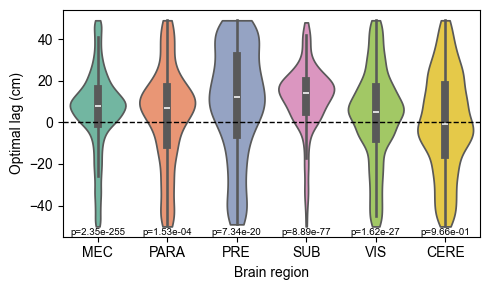

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp

# List of brain regions and their dataframes
regions = ['MEC', 'PARA', 'PRE', 'SUB', 'VIS', 'CERE']
dfs = [MEC_, PARA_, PRE_, SUB_, VIS_, CERE_]

# Collect data for plotting
data = []
for region, df in zip(regions, dfs):
    for val in df['optimal_travel_lag']:
        data.append({'region': region, 'optimal_travel_lag': val})

plot_df = pd.DataFrame(data)

# Compute p-values for one-sample t-test against 0
pvals = []
for region, df in zip(regions, dfs):
    vals = df['optimal_travel_lag'].dropna()
    if len(vals) > 0:
        tstat, pval = ttest_1samp(vals, 0)
    else:
        pval = np.nan
    pvals.append(pval)

# Make violin plot
fig, ax = plt.subplots(figsize=(5, 3))
sns.violinplot(
    data=plot_df, 
    x='region', 
    y='optimal_travel_lag', 
    ax=ax, 
    palette='Set2',
    cut=0
)

# Annotate p-values at the bottom of each violin
for i, pval in enumerate(pvals):
    ax.text(i, ax.get_ylim()[0], f"p={pval:.2e}", ha='center', va='bottom', fontsize=7, color='black')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('Optimal lag (cm)')
ax.set_xlabel('Brain region')
fig.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_lag_by_brain_region.pdf', bbox_inches='tight')
plt.show()

In [7]:
print(f'unique brain_regions in other {other_.brain_region.unique()}')

unique brain_regions in other ['HPF' 'dhc' 'or' 'ec' 'fp' 'alv' 'POST' 'mcp' 'CUL4, 5' 'APr' 'RSPd6a']
